In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [37]:
df = pd.read_csv('ushape.csv')
df.columns = ["X","Y","Class"]
df.head()

,X,Y,Class
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


In [38]:
X = df.iloc[:,:2]
y = df.iloc[:,-1]

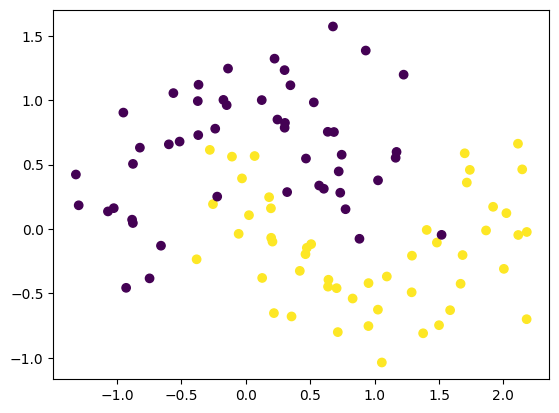

In [39]:
plt.scatter(X.iloc[:,:1] , X.iloc[:,1:] , c = y)

In [40]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.layers import Dense
from keras import Sequential
from keras import initializers

In [41]:
model = Sequential()

intializer = tf.keras.initializers.GlorotNormal()
model.add(Dense(8,activation = "relu",input_dim = 2,kernel_initializer = intializer))
model.add(Dense(4,activation = "relu",kernel_initializer = intializer))
model.add(Dense(1,activation = "sigmoid",kernel_initializer = intializer))

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

In [42]:
model.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])

In [43]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.5063 - loss: 0.6657 - val_accuracy: 0.5000 - val_loss: 0.6609
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5063 - loss: 0.6641 - val_accuracy: 0.5000 - val_loss: 0.6589
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5063 - loss: 0.6626 - val_accuracy: 0.5000 - val_loss: 0.6568
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4937 - loss: 0.6611 - val_accuracy: 0.5000 - val_loss: 0.6547
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4937 - loss: 0.6597 - val_accuracy: 0.5000 - val_loss: 0.6527
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4937 - loss: 0.6581 - val_accuracy: 0.5000 - val_loss: 0.6508
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4810 - loss: 0.6567 - val_accuracy: 0.4500 - val_loss: 0.6487
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5190 - loss: 0.6552 - val_accuracy: 0.4500 - val_loss

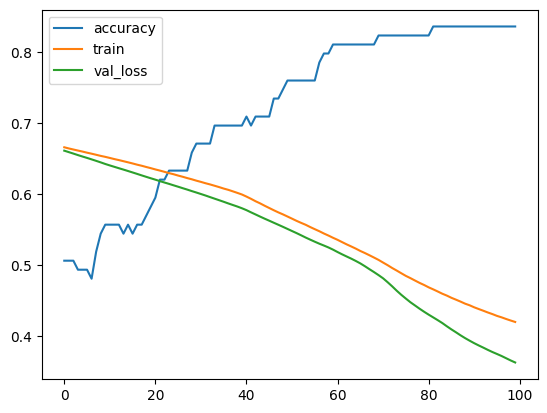

In [44]:
plt.plot(history.history["accuracy"],label="accuracy")
plt.plot(history.history["loss"],label="train")
plt.plot(history.history["val_loss"],label="val_loss")
plt.legend()

In [45]:
X = X.to_numpy()
y = y.to_numpy()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


<Axes: >

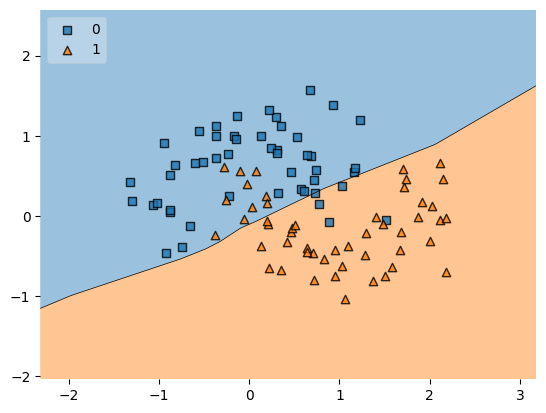

In [46]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

#when we took relu plus He Normal

In [47]:
#now lets make model with same network for he uniform

In [53]:
model2 = Sequential()

intializer = tf.keras.initializers.GlorotUniform()
model2.add(Dense(8,activation = "relu",input_dim = 2,kernel_initializer = intializer))
model2.add(Dense(4,activation = "relu",kernel_initializer = intializer))
model2.add(Dense(1,activation = "sigmoid",kernel_initializer = intializer))

model2.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

In [54]:
model2.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])

In [55]:
history = model2.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 166ms/step - accuracy: 0.6582 - loss: 0.6908 - val_accuracy: 0.8500 - val_loss: 0.6881
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.7595 - loss: 0.6901 - val_accuracy: 0.8500 - val_loss: 0.6876
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7975 - loss: 0.6895 - val_accuracy: 0.8500 - val_loss: 0.6870
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8101 - loss: 0.6891 - val_accuracy: 0.8500 - val_loss: 0.6865
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8101 - loss: 0.6886 - val_accuracy: 0.8500 - val_loss: 0.6859
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8101 - loss: 0.6882 - val_accuracy: 0.8500 - val_loss: 0.6853
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8101 - loss: 0.6878 - val_accuracy: 0.8500 - val_loss: 0.6846
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8101 - loss: 0.6873 - val_accuracy: 0.8500 - val_loss

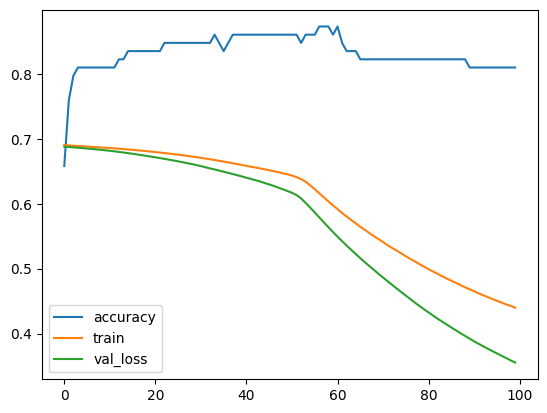

In [56]:
plt.plot(history.history["accuracy"],label="accuracy")
plt.plot(history.history["loss"],label="train")
plt.plot(history.history["val_loss"],label="val_loss")
plt.legend()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


<Axes: >

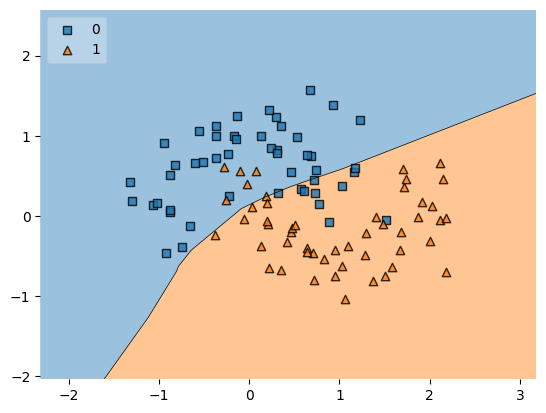

In [57]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model2, legend=2)

#when we took relu plus He Uniform